# SMART DSS Sensitivity Analysis

This notebook evaluates how predefined changes in decision-maker preferences affect the SMART ranking of Vietnamese ETFs. It is read-only: it does not modify database data, create predictions, or calculate BUY/HOLD/SELL recommendations.

## 1. Methodology

SMART sensitivity analysis keeps the ETF universe, as-of date, raw criteria, and normalized utilities fixed. It then applies three predefined weight profiles to the same utilities. This isolates the effect of changing criterion weights.

Rank change convention: `rank_change = balanced_rank - scenario_rank`. A positive value means the ETF moved upward under the scenario, a negative value means it moved downward, and zero means unchanged.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "backend").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

BACKEND_ROOT = PROJECT_ROOT / "backend"
if str(BACKEND_ROOT) not in sys.path:
    sys.path.insert(0, str(BACKEND_ROOT))

from app.db.session import SessionLocal
from app.services.dss_service import (
    SMART_WEIGHT_PROFILES,
    calculate_sensitivity_analysis_from_database,
)

plt.style.use("default")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

SMART_WEIGHT_PROFILES

{'BALANCED': {'technical_momentum': 0.3,
  'return_20d': 0.25,
  'volatility_20d': 0.2,
  'max_drawdown_60d': 0.15,
  'avg_volume_20d': 0.1},
 'GROWTH': {'technical_momentum': 0.35,
  'return_20d': 0.35,
  'volatility_20d': 0.1,
  'max_drawdown_60d': 0.1,
  'avg_volume_20d': 0.1},
 'RISK_AVERSE': {'technical_momentum': 0.2,
  'return_20d': 0.15,
  'volatility_20d': 0.3,
  'max_drawdown_60d': 0.25,
  'avg_volume_20d': 0.1}}

## 2. Load Current ETF SMART Criteria Read-Only

The backend service loads the current ETF raw criteria from PostgreSQL, normalizes criteria once across the same ETF universe, and then reuses those utilities for all scenarios.

In [2]:
with SessionLocal() as session:
    sensitivity = calculate_sensitivity_analysis_from_database(session)

sensitivity.as_of_date

datetime.date(2026, 8, 21)

In [3]:
def ranking_frame(scenario_name):
    ranking = sensitivity.scenario_rankings[scenario_name]
    return pd.DataFrame(
        [
            {
                "rank": item.rank,
                "symbol": item.symbol,
                "smart_score": item.smart_score,
            }
            for item in ranking.rankings
        ]
    )

comparison_df = pd.DataFrame([item.__dict__ for item in sensitivity.comparisons])
comparison_df

,symbol,balanced_score,balanced_rank,growth_score,growth_rank,risk_averse_score,risk_averse_rank,growth_rank_change,risk_averse_rank_change
0,E1VFVN30,77.85,1,78.89,1,76.15,1,0,0
1,FUEDCMID,64.24,3,74.62,3,48.86,4,0,-1
2,FUESSVFL,58.89,4,67.48,4,48.36,5,0,-1
3,FUEVFVND,66.12,2,78.73,2,50.04,3,0,-1
4,FUEVN100,36.00,5,21.00,5,56.00,2,0,3


## 3. Baseline Balanced Ranking

Balanced uses the default SMART weights used by the DSS ranking: technical momentum and return are important, while volatility, drawdown, and volume provide risk/liquidity context.

In [4]:
balanced_df = ranking_frame("BALANCED")
balanced_df

,rank,symbol,smart_score
0,1,E1VFVN30,77.85
1,2,FUEVFVND,66.12
2,3,FUEDCMID,64.24
3,4,FUESSVFL,58.89
4,5,FUEVN100,36.00


## 4. Growth-Oriented Scenario

Growth gives higher weight to technical momentum and recent 20-day return, while reducing the weights assigned to volatility and drawdown.

In [5]:
growth_df = ranking_frame("GROWTH")
growth_df

,rank,symbol,smart_score
0,1,E1VFVN30,78.89
1,2,FUEVFVND,78.73
2,3,FUEDCMID,74.62
3,4,FUESSVFL,67.48
4,5,FUEVN100,21.00


## 5. Risk-Averse Scenario

Risk-Averse gives higher weight to 20-day volatility and 60-day maximum drawdown, while reducing emphasis on technical momentum and recent return.

In [6]:
risk_averse_df = ranking_frame("RISK_AVERSE")
risk_averse_df

,rank,symbol,smart_score
0,1,E1VFVN30,76.15
1,2,FUEVN100,56.00
2,3,FUEVFVND,50.04
3,4,FUEDCMID,48.86
4,5,FUESSVFL,48.36


## 6. Ranking Comparison Table

This table compares scores and ranks across the three scenarios. Positive rank change means the ETF moved upward relative to the Balanced ranking.

In [7]:
comparison_df.sort_values("balanced_rank")

,symbol,balanced_score,balanced_rank,growth_score,growth_rank,risk_averse_score,risk_averse_rank,growth_rank_change,risk_averse_rank_change
0,E1VFVN30,77.85,1,78.89,1,76.15,1,0,0
3,FUEVFVND,66.12,2,78.73,2,50.04,3,0,-1
1,FUEDCMID,64.24,3,74.62,3,48.86,4,0,-1
2,FUESSVFL,58.89,4,67.48,4,48.36,5,0,-1
4,FUEVN100,36.00,5,21.00,5,56.00,2,0,3


## 7. Score Comparison Chart

The grouped bar chart shows how each ETF's SMART score changes when only the weight profile changes.

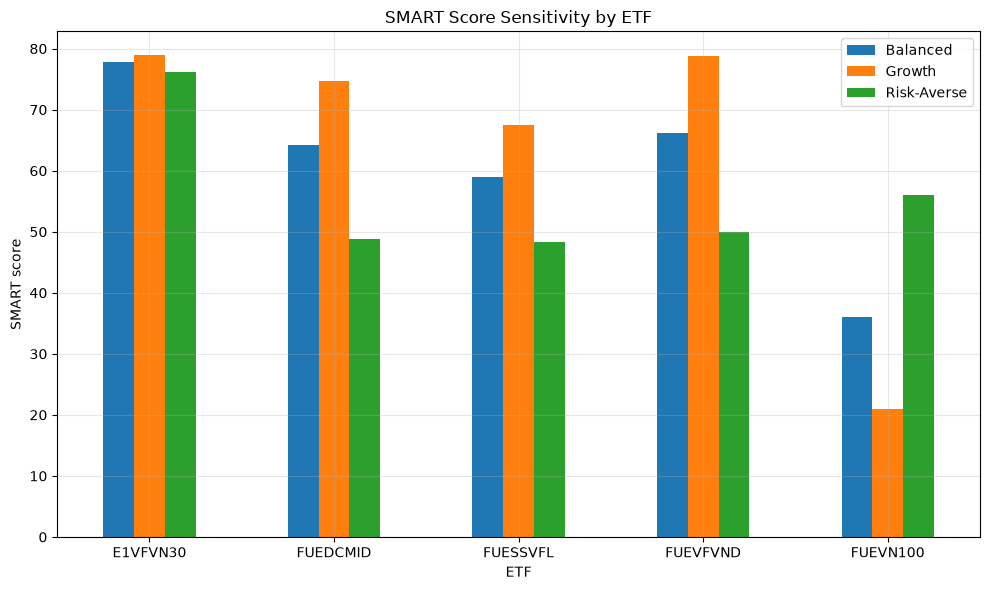

In [8]:
score_df = comparison_df.set_index("symbol")[[
    "balanced_score",
    "growth_score",
    "risk_averse_score",
]]
score_df.plot(kind="bar")
plt.title("SMART Score Sensitivity by ETF")
plt.ylabel("SMART score")
plt.xlabel("ETF")
plt.xticks(rotation=0)
plt.legend(["Balanced", "Growth", "Risk-Averse"])
plt.tight_layout()
plt.show()

## 8. Rank-Change Discussion

Rank changes highlight whether ETF ordering is sensitive to decision-maker preferences. Stable ranks indicate that the ranking is less affected by the tested preference changes.

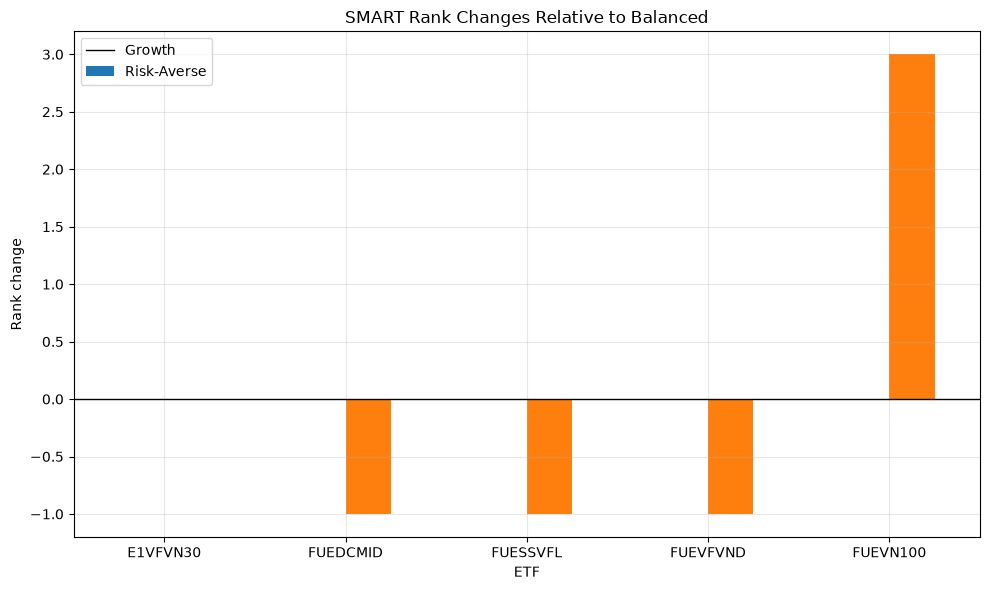

In [9]:
rank_change_df = comparison_df.set_index("symbol")[[
    "growth_rank_change",
    "risk_averse_rank_change",
]]
rank_change_df.plot(kind="bar")
plt.axhline(0, color="black", linewidth=1)
plt.title("SMART Rank Changes Relative to Balanced")
plt.ylabel("Rank change")
plt.xlabel("ETF")
plt.xticks(rotation=0)
plt.legend(["Growth", "Risk-Averse"])
plt.tight_layout()
plt.show()

## 9. Conclusion

The stability summary below reports whether the top-ranked ETF remains the same across all scenarios, the largest absolute rank movement, and how many ETFs change rank in the Growth and Risk-Averse scenarios.

In [10]:
sensitivity.stability_summary.__dict__

{'top_etf_stable': True,
 'max_absolute_rank_change': 3,
 'growth_changed_count': 0,
 'risk_averse_changed_count': 4}